# R-KV Token Dropping — Route A, exact and linear, on the CPU
---

Long prompts create large KV caches. They eat GPU memory, limit how many requests
fit in a batch, and a smaller batch means lower decode throughput. *Token
dropping* shrinks each request's KV cache — by half in this notebook — so more
requests fit and decoding runs faster.

This notebook uses the LMCache SDK to pull a request's KV cache out after
prefill, compress it, and put it back before decode. The compression algorithm
is **R-KV**: it ranks past tokens by **attention importance**, like SnapKV, and
subtracts a second term, **redundancy** — how similar a token's key is to the
*other* keys:

$$\text{score}(j) \;=\; \lambda \cdot \underbrace{\text{importance}(j)}_{\text{attended to?}} \;-\; (1-\lambda) \cdot \underbrace{\text{redundancy}(j)}_{\text{says something new?}}$$

Keeping tokens that are both attended-to **and** non-redundant works especially
well on the repetitive output of reasoning models. The catch is that the
redundancy term compares **all pairs of keys**: $O(n^2 d)$ per layer, against
$O(w n d)$ for SnapKV's importance term. At $n = 16128$ with window $w = 64$
that is ~250x more arithmetic per layer, and a literal implementation also
materializes an $n \times n$ matrix per layer.

## This notebook

It implements the redundancy term **exactly, in linear time, entirely on the
CPU**. R-KV never actually needs the $n \times n$ matrix — the only thing that
leaves it is a column sum, and a column sum of an inner product factors into a
single dot product. The result is bit-for-bit the same tokens as the reference
at $O(n d)$ plus a short scan, with the GPU left entirely to the serving engine.

It is one of four independent notebooks that keep the same 50% of the tokens and
therefore deliver the **same decode speed-up** — 1766–1785 tok/s, a 1.1% spread, even
though they compress with completely different code. What separates them is the **cost of
compressing**:

| | [one-shot](../rkv_token_dropping.ipynb) | [cpu_exact](./rkv_variant_cpu_exact.ipynb) | [gpu_exact](./rkv_variant_gpu_exact.ipynb) | [buffered_cpu](./rkv_variant_buffered_cpu.ipynb) |
|---|---|---|---|---|
| Formulation | route A, literal | route A, linear | route A, linear | route B, chunked |
| Exact? | yes (the reference) | yes, rel. err ~2e-6 | yes, rel. err ~5e-7 | **no**, ~96% agreement |
| Redundancy cost | $O(n^2 d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ | $O(n \cdot c \cdot d)$ |
| VRAM | ~9.8 GiB | none | **1.55 GiB** | none |
| Compress 30 requests | 41.6 s | 67.3 s | **37.5 s** | **29.9 s** |
| Decode throughput | 1766 tok/s | 1785 tok/s | 1774 tok/s | 1774 tok/s |
| Accuracy (baseline 10–11/30) | 13/30 | 14/30 | 14/30 | 13/30 |


Start with the [one-shot notebook](../rkv_token_dropping.ipynb): it is R-KV
written the way the paper describes it, and it is the reference the exact
variants here are checked against.

Numbers above were measured on 30 LongBench-v2 prompts (~16k tokens each) with
Qwen3-8B on one H200 and a 96-core Xeon. They are hardware- and
workload-dependent; treat them as reference measurements, not guarantees.

## Requirements

* A small ~10-line modification to vLLM exposes intermediate tensors to LMCache.
  See [README.md](../README.md).
* A GPU is required for serving. To see token dropping increase the decode batch
  size, tune the GPU memory utilization together with the number of requests.
* Data moves between the LMCache server and the SDK through shared memory; if it
  is unavailable the SDK falls back to pickle.
* Run this notebook from its own directory; it imports `../utils.py`.


## Setup vLLM and LMCache server
Follow below instructions (1-4), then proceed to below Python cell.

**1. Start LMCache server first**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`

```sh
lmcache server \
    --l1-size-gb 400 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8080 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query
```

**2. Wait until LMCache server is ready**

```sh
curl -sf http://localhost:8080/healthcheck && echo " LMCache ready"
```

**3. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching. 
This ensures the prefilled KV cache is always served from LMCache rather than 
vLLM, so the decoding throughput improvement can be attributed entirely to the 
tokens dropped through LMCache.

```sh
LMCACHE_TRANSFER_INTERMEDIATE_TENSORS=true \
vllm serve Qwen/Qwen3-8B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-8B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.65 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids
```

**4. Wait until vLLM is ready**

```sh
curl -sf http://localhost:8000/v1/models && echo " vLLM ready"
```

In [1]:
# SPDX-License-Identifier: Apache-2.0
"""End-to-end KV cache remapping driver for the SDK example."""

# Standard
from datasets import load_dataset
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once

sys.path.append("..")  # utils.py lives next to the main notebook

from utils import (  # noqa: E402
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-08-01 06:10:44,673] LMCache INFO: torch_dev=<module 'torch.cuda' from '/home/sigma/github/LMCache/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)


[2026-08-01 06:10:44,752] LMCache INFO: multi_layer_block_kv_transfer mode: ptr (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.3rc2.dev2 (g6018f8af)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [2]:
model_name = "/data/models/Qwen3-8B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8080"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 5120
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

# Streams prefilled per submission. LMCache's query ring buffer maps a forward
# step's query rows to ring slots positionally (qringbuffer.py
# build_q_step_state), assuming each request contributed exactly its store op's
# token count of rows. Continuous batching breaks that, so the captured queries
# are silently wrong or short. Measured query-row reproducibility across two
# identical runs: 100.0% at 1 stream, 99.7% at 4, 9.8% at 30. R-KV's importance
# term is entirely query-driven, so prefill is submitted one stream at a time.
prefill_group_size = 1

## Configuring the model and LMCache endpoint

In [3]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
head_size = getattr(
    config, "head_dim", config.hidden_size // config.num_attention_heads
)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-08-01 06:10:45,198] LMCache INFO: Initialized LMCacheSDKContext with instance_id=2954723088406771601, model_name=/data/models/Qwen3-8B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:122:lmcache.sdk.context)


[2026-08-01 06:10:45,201] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-01 06:10:45,369] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-01 06:10:45,374] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_TWO_NH_BS_HS NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-01 06:10:45,376] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=429496729600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


...

[2026-08-01 06:11:15,475] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)


[2026-08-01 06:11:15,475] LMCache INFO: Engine KV Format: EngineKVFormat.NL_X_NB_BS_HS NL x [NB, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)


[2026-08-01 06:11:15,477] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=429496729600) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)


[2026-08-01 06:11:45,154] LMCache INFO: SHM pinned=True for shm_name=lmcache_l1_pool_lmcache_sdk (shm.py:118:lmcache.v1.multiprocess.transfer_context.shm)


[2026-08-01 06:11:45,156] LMCache INFO: Worker non-GPU transfer context registered (instance_id=2015722103783686033, mode=SHM) (worker_transfer.py:745:lmcache.v1.multiprocess.transfer_context.worker_transfer)


## Constructing Prompt

In [4]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo", split="train")
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

Loaded 30 prompts from the dataset.
Total prompts length: 423428 tokens.
Mean prompt length: 14114.27 tokens.
Max prompt length: 16807 tokens.
Min prompt length: 10159 tokens.


## Baseline (without token dropping)


In [5]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-01 06:13:22,563] LMCache INFO: prefill: 15.21 s in groups of 1 (420791162.py:24:__main__)


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                       153.11
Total Output Tokens:                                                      153392
Decode Throughput (tokens/s):                                            1001.81


## Clear LMCache


In [6]:
!curl -X POST {lmcache_url}/cache/clear


{"status":"ok","cleared":{"tier":"l1"}}

## With R-KV Token Dropping — Route A, exact and linear, on the CPU

In [7]:
# Standard
import os

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
rkv_window_size = 8  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.07  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"

# --- CPU thread budget (shared by both CPU implementations) ------------------
cpu_thread_oversubscription = 1.25  # total intra-op threads / usable cores
cpu_reserve_cores = 4  # left for vLLM, the LMCache server and the OS
cpu_device = torch.device("cpu")


def usable_cores():
    """Cores this process may actually run on -- affinity and cgroup, not nproc."""
    try:
        cores = len(os.sched_getaffinity(0))
    except AttributeError:
        cores = os.cpu_count() or 1
    try:
        with open("/sys/fs/cgroup/cpu.max") as fh:
            quota, period = fh.read().split()
        if quota != "max":
            cores = min(cores, max(1, int(int(quota) // int(period))))
    except (OSError, ValueError):
        pass
    return max(1, cores)


def plan_cpu_threads():
    """Set torch's intra-op threads so intra_op * workers ~= 1.25 * cores.

    `batch.modify` runs one worker thread per stream and torch defaults to one
    intra-op thread per core inside each of them, which on a 96-core box means
    30 x 96 = 2880 runnable threads. Measured over 30 requests: 27.6 s at 96
    intra-op threads, 19.8 s at 4, 33.5 s at 1.
    """
    cores = usable_cores()
    budget = max(1, round((cores - cpu_reserve_cores) * cpu_thread_oversubscription))
    workers = max(1, len(prompts))
    intra_op = max(1, min(budget // workers, budget))
    torch.set_num_threads(intra_op)
    logger.info(
        f"CPU thread plan: {cores} usable cores -> budget {budget}, "
        f"{workers} workers -> torch.set_num_threads({intra_op}) "
        f"(~{intra_op * workers} runnable threads)"
    )
    return intra_op


cpu_intraop_threads = plan_cpu_threads()


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = (
        flat.to(dtype=torch.float32)
        if device is None
        else flat.to(device, torch.float32)
    )
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=rkv_sim_threshold):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()

[2026-08-01 06:15:55,884] LMCache INFO: CPU thread plan: 96 usable cores -> budget 115, 30 workers -> torch.set_num_threads(3) (~90 runnable threads) (3911048703.py:49:__main__)


### Route A, exact and linear, on the CPU

> **Trades compression latency for zero VRAM.** Exactly the same tokens as
> the [one-shot notebook](../rkv_token_dropping.ipynb), computed in linear time, without touching the GPU at all —
> but it is the slowest of the four and it does spend the machine's cores.
>
> | | |
> |---|---|
> | **Buys you** | **No VRAM at all** — the whole GPU stays with the serving engine; still exact; linear in $n$ |
> | **Costs you** | The slowest compression of the four, and ~90 CPU threads while it runs |
> | Exact? | Yes — relative error ~2e-6, identical kept-token set |
> | VRAM | None |
> | Compress 30 requests | 67.3 s |
> | Decode throughput | 1785 tok/s |
> | Pick it when | The GPU is saturated by serving and you have CPU to spare |

The [one-shot implementation](../rkv_token_dropping.ipynb) is expensive
because it takes the $n \times n$ matrix literally. It turns out **R-KV never needs that matrix**. What follows produces
*bit-for-bit the same scores* at $O(n \cdot d)$ plus a short scan — no
approximation, no GPU.

## What redundancy actually is

Write $\hat{k}_i$ for token $i$'s key, normalised to unit length, so that
$\langle \hat{k}_i, \hat{k}_j \rangle$ is exactly the cosine similarity between
tokens $i$ and $j$. R-KV builds the matrix $S_{ij} = \langle \hat{k}_i, \hat{k}_j \rangle$
and then:

1. zeroes the diagonal — a token is not redundant with itself;
2. for each **row** $i$, finds the *largest* column index $j$ with $S_{ij} > \tau$
   and zeroes that one entry (the `similarity_retain` rule: a token's single
   most recent look-alike is spared, so a pair of duplicates does not delete
   each other);
3. reduces with a **mean down each column**, then a softmax across columns.

Step 3 is the important one. The only thing that leaves the matrix is a **column
sum**. Every individual $S_{ij}$ is discarded.

## Turning the column sum into one dot product

A column sum of an inner product can be factored, because the inner product is
linear in its first argument:

$$
\sum_i \langle \hat{k}_i, \hat{k}_j \rangle
\;=\; \Big\langle \underbrace{\sum_i \hat{k}_i}_{\text{one vector, } s} ,\; \hat{k}_j \Big\rangle
$$

Sum the keys **first** ($O(n \cdot d)$), then take one dot product per token
($O(n \cdot d)$). The $n^2$ matrix disappears.

The two zeroing steps are then exact corrections on top:

* **the diagonal** — subtract $\langle \hat{k}_j, \hat{k}_j \rangle$ from column $j$;
* **the retain rule** — row $i$ removed one entry, in column $r(i)$, of value
  $S_{i,r(i)}$. Subtract each of those from its column. Several rows can share a
  column, so this is a `scatter_add`, not an assignment.

## The one part that still needs pairs

Finding $r(i)$ — the largest column above threshold in row $i$ — genuinely needs
pairwise comparisons. But it can be searched **right to left in column blocks**:
because blocks further right are visited first, the *first* hit a row sees is
already its answer, and that row can be retired.

That is cheap on real data because language-model key vectors are strongly
anisotropic — they share a large common direction, so most pairs are similar.
Measured on this model's own KV cache:

| layer | mean pairwise cosine | rows that hit inside the last 1024 columns |
|---|---|---|
| 0 | 0.988 | 100.00% |
| 8 | 0.753 | 99.99% |
| 17 | 0.433 | 93.63% |
| 26 | 0.403 | 87.80% |
| 35 | 0.730 | 99.99% |

With a 2048-column first block, only **~2%** of rows survive it. The total cost
is $O(n \cdot \text{col\_block} \cdot d)$ plus a negligible tail — **linear in
$n$**, so the advantage grows with prompt length.

## What was optimized

| # | Change | Why it mattered |
|---|---|---|
| 1 | **Batch the first block over heads; gather only the residual.** | A first attempt looped over heads for *every* block and was **not faster than the reference** despite touching only 10% of the matrix: in the first block every row is active, so gathering them copied the whole tensor for nothing and threw away the batched GEMM. Fixing this took it from 1.5× to 4.2×. |
| 2 | **Per-head active sets in the residual scan.** | Sharing one row set across heads looks tidier, but with per-head hit rates around 0.88 the chance that *all 8* heads are done with a row is $0.88^8 \approx 0.36$ — two thirds of rows stay "active" although nearly every head has retired them. |
| 3 | **`col_block = 2048`.** | Smaller blocks touch less of the matrix but pay more Python and gather overhead: 3.4% of the matrix at 256 took **0.99 s/layer**, while 20.5% at 2048 took **0.062 s/layer**. |
| 4 | **fp32, not bf16.** | This Xeon has AMX-BF16, yet bf16 was *slower*. Once the matrix is gone the kernel is bound by the compare / flip / argmax / scatter — memory-bound ops AMX does not help — and fp32 keeps the threshold comparison exact. |
| 5 | **Thread planning.** | `batch.modify` already gives 30-way outer parallelism and torch defaults to one intra-op thread *per core inside each worker* — 30 × 96 = 2880 runnable threads. Measured: 27.6 s at 96 intra-op threads, **19.8 s at 4**, 33.5 s at 1. The optimum sits near 1.25 × cores in total, derived from the cores this process may *actually* use (CPU affinity and cgroup quota, not the raw count). |

**Result: 8.0 s → 1.9 s per request (4.2×), relative error ~2e-6, no GPU.**


In [8]:
# --- Knobs -------------------------------------------------------------------
# Columns scanned per block. Bigger blocks retire more rows up front but touch
# more of the matrix; 2048 was the measured optimum. (Threads are budgeted once
# in the shared cell above.)
cpu_col_block = 2048


def _linear_redundancy(key_states, col_block):
    """Exact route A redundancy in O(n * col_block * d).

    key_states: [1, kv_heads, n, d] -> [1, kv_heads, n]
    """
    _, kv_heads, n, _ = key_states.shape
    k = key_states[0]
    k = k / (k.norm(dim=-1, keepdim=True) + 1e-8)
    cb = max(1, min(col_block, n))

    # The whole column sum, without the matrix: sum_i <k_i, k_j> = <sum_i k_i, k_j>.
    s = k.sum(dim=-2, keepdim=True)
    col_sum = (k * s).sum(dim=-1) - (k * k).sum(dim=-1)  # minus the diagonal

    # Rows that never clear the threshold exempt column 0, whose values are
    # another O(n d) product. Row 0's own diagonal was already removed.
    retain_col = torch.zeros((kv_heads, n), dtype=torch.long)
    retain_val = torch.matmul(k, k[:, :1, :].transpose(-1, -2)).squeeze(-1).clone()
    retain_val[:, 0] = 0.0

    # Rightmost block: every row is active, so run it batched with no gather.
    c0 = max(0, n - cb)
    width = n - c0
    blk = torch.matmul(k, k[:, c0:n, :].transpose(-1, -2))
    diag = torch.arange(c0, n)
    blk[:, diag, diag - c0] = 0.0
    over = blk > rkv_sim_threshold
    has = over.any(dim=-1)
    last = (width - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
    val = blk.gather(-1, last.unsqueeze(-1)).squeeze(-1)
    retain_col = torch.where(has, last + c0, retain_col)
    retain_val = torch.where(has, val, retain_val)
    del blk, over, last, val

    # Residual rows only, per head -- typically ~2% of them.
    for h in range(kv_heads):
        act = (~has[h]).nonzero(as_tuple=False).squeeze(-1)
        kh = k[h]
        for c1 in range(c0, 0, -cb):
            if act.numel() == 0:
                break
            c0b, w = max(0, c1 - cb), c1 - max(0, c1 - cb)
            sub = torch.matmul(kh[act], kh[c0b:c1].transpose(0, 1))
            inb = (act >= c0b) & (act < c1)
            if bool(inb.any()):
                rr = inb.nonzero(as_tuple=False).squeeze(-1)
                sub[rr, act[rr] - c0b] = 0.0
            ov = sub > rkv_sim_threshold
            hs = ov.any(dim=-1)
            lst = (w - 1) - ov.flip(-1).to(torch.uint8).argmax(dim=-1)
            # Blocks further right were scanned first, so this IS the maximum.
            retain_col[h, act[hs]] = lst[hs] + c0b
            retain_val[h, act[hs]] = sub.gather(-1, lst.unsqueeze(-1)).squeeze(-1)[hs]
            act = act[~hs]
            del sub, ov, hs, lst

    col_sum.scatter_add_(-1, retain_col, -retain_val)
    return (col_sum / n).softmax(dim=-1).unsqueeze(0)


def drop_tokens_cpu_exact(tensors, token_source):
    """Exact route A token dropping, entirely on the CPU."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    num_q, num_kv, head_dim = model_heads()

    scores = torch.zeros(past_len, dtype=torch.float32)
    for layer in range(kv.shape[1]):
        k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim)
        qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim)
        imp = importance(k, qw, past_len)
        red = _linear_redundancy(k, cpu_col_block)[:, :, :past_len]
        scores += (imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)).mean(1).squeeze(0)

    keep_idx = select(scores, past_len, seq_len, keep_past)
    e_kv = rerotate(kv, keep_idx, cpu_device)
    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_cpu_exact(n=3000, layers=3):
    """This is a rewrite, not an approximation, so demand equality.

    n is deliberately not a multiple of col_block so the ragged block is used.
    """
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    keep = int(round(n * (1 - rkv_drop_ratio))) - rkv_window_size
    worst, ref_tot, got_tot = 0.0, torch.zeros(n), torch.zeros(n)

    for i in range(layers):
        # Mix in a shared direction so some pairs clear the threshold and the
        # retain path is actually exercised.
        mu = torch.randn(1, num_kv, 1, head_dim)
        k = torch.randn(1, num_kv, n, head_dim)
        k = 0.6 * mu + 0.4 * k if i % 2 == 0 else k
        ref, got = redundancy_reference(k), _linear_redundancy(k, cpu_col_block)
        worst = max(worst, ((ref - got).abs().max() / ref.abs().max()).item())
        ref_tot += ref.mean(dim=1).squeeze(0)
        got_tot += got.mean(dim=1).squeeze(0)

    same = torch.equal(
        torch.topk(ref_tot, keep).indices.sort().values,
        torch.topk(got_tot, keep).indices.sort().values,
    )
    logger.info(
        f"CPU exact self-test: max relative error {worst:.2e}, "
        f"kept-token set {'IDENTICAL' if same else 'DIFFERS'}"
    )
    assert worst < 1e-4 and same, "the linear rewrite is not route A"


_selftest_cpu_exact()

[2026-08-01 06:15:56,909] LMCache INFO: CPU exact self-test: max relative error 5.71e-07, kept-token set IDENTICAL (301996112.py:112:__main__)


In [9]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    stream = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(stream)
    stream_ids.append(stream.request_stream_id)

# temperature 0 here too: prefill emits one token that is APPENDED to the
# stream, so sampling it would make the whole greedy decode below depend on a
# random first token. Groups of `prefill_group_size` keep the query capture
# correct (see the hyperparameter cell).
prefill_seconds = 0.0
for g0 in range(0, len(stream_ids), prefill_group_size):
    results = batch.prefill(
        sampling_params={"max_tokens": 1, "temperature": 0.0, "ignore_eos": True},
        stream_ids=stream_ids[g0 : g0 + prefill_group_size],
    )
    prefill_seconds += results.to_dict()["metrics"]["results"].get("duration", 0.0)
logger.info(f"prefill: {prefill_seconds:.2f} s in groups of {prefill_group_size}")

results = batch.modify(drop_tokens_cpu_exact)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
cpu_exact_drop_data = results.to_dict()
cpu_exact_texts = [stream.output_text for stream in batch.request_streams.values()]

[2026-08-01 06:16:12,184] LMCache INFO: prefill: 15.23 s in groups of 1 (3598385456.py:24:__main__)


[2026-08-01 06:16:56,624] LMCache INFO: compacted 5120/10240 tokens. (301996112.py:83:__main__)


[2026-08-01 06:16:57,228] LMCache INFO: compacted 4992/9984 tokens. (301996112.py:83:__main__)


[2026-08-01 06:16:58,349] LMCache INFO: compacted 5632/11264 tokens. (301996112.py:83:__main__)


[2026-08-01 06:17:00,456] LMCache INFO: compacted 5376/10752 tokens. (301996112.py:83:__main__)


...

[2026-08-01 06:17:18,850] LMCache INFO: compacted 8064/16128 tokens. (301996112.py:83:__main__)


[2026-08-01 06:17:19,244] LMCache INFO: compacted 8320/16640 tokens. (301996112.py:83:__main__)


[2026-08-01 06:17:19,497] LMCache INFO: 

 (3598385456.py:29:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        67.31


======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    30
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        85.90
Total Output Tokens:                                                      153359
Decode Throughput (tokens/s):                                            1785.26


### Accuracy


In [10]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, cpu_exact_texts)

logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"R-KV CPU exact: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-08-01 06:18:45,419] LMCache INFO: Baseline (no drop): 11/30 correct (36.7%) (1792173437.py:4:__main__)


[2026-08-01 06:18:45,420] LMCache INFO: R-KV CPU exact: 14/30 correct (46.7%) (1792173437.py:8:__main__)


## Result Plot


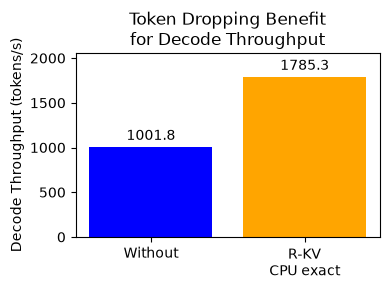

In [11]:
labels = ["Without", "R-KV\nCPU exact"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    cpu_exact_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(4, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Reading these numbers

All four notebooks were run back to back on one machine against the same vLLM
and LMCache servers, and each re-measures its own no-drop baseline. That gives
four independent measurements of an **identical** configuration — a direct read
on how much of any difference is real:

| | one-shot | gpu_exact | cpu_exact | buffered_cpu |
|---|---|---|---|---|
| baseline decode | 969 tok/s | 1008 tok/s | 1002 tok/s | 975 tok/s |
| baseline accuracy | 10/30 | 10/30 | 11/30 | 11/30 |
| decode after dropping | 1766 tok/s | 1774 tok/s | 1785 tok/s | 1774 tok/s |
| accuracy after dropping | 13/30 | 14/30 | 14/30 | 13/30 |

Three things follow.

1. **Decode throughput after dropping is the solid number.** It lands in
   1766–1785 tok/s — a 1.1% spread — although the four notebooks compress with
   completely different code. That is the claim this example makes: the speed-up
   comes from halving the KV cache, not from how the halving is computed.

2. **Don't quote a speed-up ratio.** The no-drop baseline swung 969–1008 tok/s
   here, and 894–1076 tok/s — **20%** — over an earlier sweep of the same four
   notebooks, so the ratio moves between 1.6x and 2.0x on noise alone. Compare
   the absolute post-drop throughput instead.

3. **Don't rank the variants by accuracy.** R-KV beat the same-run baseline in
   all four runs (+3 to +4 of 30), which is the meaningful result. But the 1/30
   spread *between* variants is the same size as the baseline's own spread, so
   it says nothing about the algorithms.

### Why identical inputs give different text

Decoding is greedy — `temperature = 0.0` for both prefill and decode — yet the
generated text still differs between runs. `temperature = 0` fixes the *rule*
(take the argmax); it does not make the argmax stable.

Prefill is submitted one stream at a time (`prefill_group_size = 1`) and it
**is** reproducible: 15.19 s and 15.21 s, to the same hundredth of a second, in
every notebook. Decode is not. `batch.decode` hands all 30 streams to vLLM at
once, so continuous batching gives the decode batch a different composition on
every run. GPU reductions are not batch-invariant, logits move by ~1e-6,
near-ties flip, and autoregression amplifies the divergence.

This is a property of the serving stack, not of token dropping — but it is the
reason a single accuracy number here should not be read as a ranking.

### The exact variants pick the same tokens — their caches still differ

Verified directly on real requests: `cpu_exact` and `gpu_exact` produce score
vectors that differ by ~1e-6, but the top-k they select was identical on every
request tested, and so were the kept token ids. Their compacted caches are
nevertheless not byte-identical:

| | differing elements | largest difference |
|---|---|---|
| V — a pure gather | **0** | 0 |
| K — goes through the RoPE re-rotation | 0.004% | one to two bfloat16 ULP |

Every difference is in K, and it is the *device*: `cpu_exact` re-rotates on the
CPU, `gpu_exact` on the GPU, and their sin/cos implementations and fused
multiply-adds round differently before the result is stored back as bfloat16.
Feeding one identical tensor to `rerotate_k_cache` on each device reproduces the
same signature exactly, so nothing else is involved.

One ULP in K is enough to move an attention logit, flip a near-tied greedy
argmax, and diverge from there. That is why two implementations which provably
select the same tokens still generate different text, and can land on a
different answer for one or two of the 30 questions.

#### Why the re-rotation runs in fp32

`utils.rerotate_k_cache` detaches one RoPE and attaches another: six multiplies
and two adds per element. Carrying that out in the cache's own bfloat16 rounds
at every step. Measured on keys with a standard deviation of 3:

| arithmetic | keys changed vs fp32 | rotate-away-and-back error | re-rotate 30 requests |
|---|---|---|---|
| bfloat16 | 50% | 2.5e-1 | 3.2 s |
| **fp32** (used here) | — | **6.3e-2** | 6.1 s |

fp32 costs 1.9x on the re-rotation step itself, because it moves twice the
bytes. End to end that is much less than it sounds: compressing the 30 requests
went from 41.4 to 41.6 s (one-shot), 37.3 to 37.5 s (`gpu_exact`) and 67.1 to
67.3 s (`cpu_exact`) — around +0.2 s, because `modify` spends most of its time
waiting on LMCache and the extra arithmetic fits in that slack. Only
`buffered_cpu` shows it, 27.9 to 29.9 s (+7%), because its compression is the
shortest so the re-rotation is the largest share of it. That buys a 4x better
round trip and takes an extra ULP of error off half the keys, so it is the
default. It does **not** remove the CPU/GPU split above: that is
the final rounding back to bfloat16, which is there whatever precision the
rotation is computed in.


## Close both contexts

In [12]:
# Only close the context when done.
ctx.close()
qctx.close()